# Titanic Classification Assignment

## Objective
To build classification models using the Titanic dataset and compare the performance of multiple machine learning algorithms.

## Algorithms Used
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Naive Bayes
- Random Forest
- Decision Tree

In [3]:
!pip install matplotlib seaborn pandas numpy joblib


In [4]:
import pandas as pd; import numpy as np; import matplotlib.pyplot as plt; import seaborn as sns; import joblib


In [26]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [27]:
#Load Titanic Dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [28]:
#Select Useful Columns
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [29]:
#Check Missing Values
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

In [30]:
#Handle Missing Values
df.dropna(inplace=True)

In [31]:
#Encode Categorical Data
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

In [32]:
#Features and Target
X = df.drop('survived', axis=1)
y = df['survived']

In [33]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
#Create Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

In [36]:
#Train and Evaluate All Models
results = {}

for name, model in models.items():
    if name in ["KNN", "SVM", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.7972
KNN: 0.7832
SVM: 0.8252
Naive Bayes: 0.7622
Random Forest: 0.7762
Decision Tree: 0.7203


In [37]:
#Accuracy Comparison Table
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
results_df

,Model,Accuracy
2,SVM,0.825175
0,Logistic Regression,0.797203
1,KNN,0.783217
4,Random Forest,0.776224
3,Naive Bayes,0.762238
5,Decision Tree,0.720280


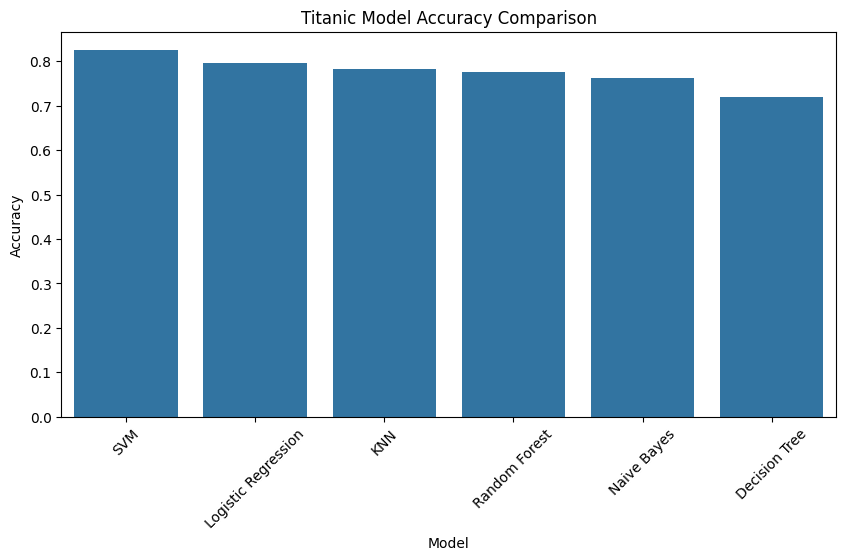

In [39]:
#Accuracy Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title("Titanic Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

In [40]:
#Best Model
best_model_name = results_df.iloc[0]['Model']
print("Best Model:", best_model_name)

Best Model: SVM


In [41]:
#Detailed Evaluation of Best Model
best_model = models[best_model_name]

if best_model_name in ["KNN", "SVM", "Logistic Regression"]:
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.80      0.91      0.85        80
           1       0.87      0.71      0.78        63

    accuracy                           0.83       143
   macro avg       0.83      0.81      0.82       143
weighted avg       0.83      0.83      0.82       143



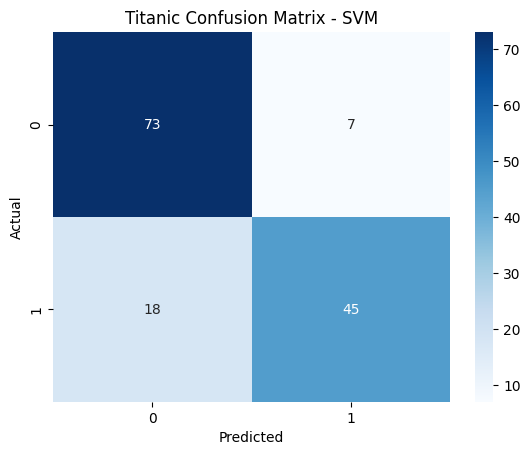

In [42]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Titanic Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [43]:
#Save Best Model
joblib.dump(best_model, '../models/titanic_best_model.pkl')


['../models/titanic_best_model.pkl']

In [44]:
joblib.dump(scaler, '../models/titanic_scaler.pkl')


['../models/titanic_scaler.pkl']

## Conclusion

Multiple classification algorithms were applied to the Titanic dataset.
The best-performing model was selected based on accuracy and saved for future use.